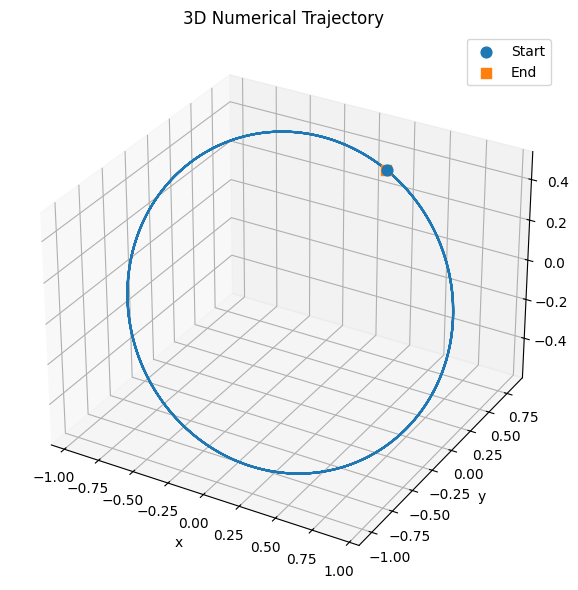

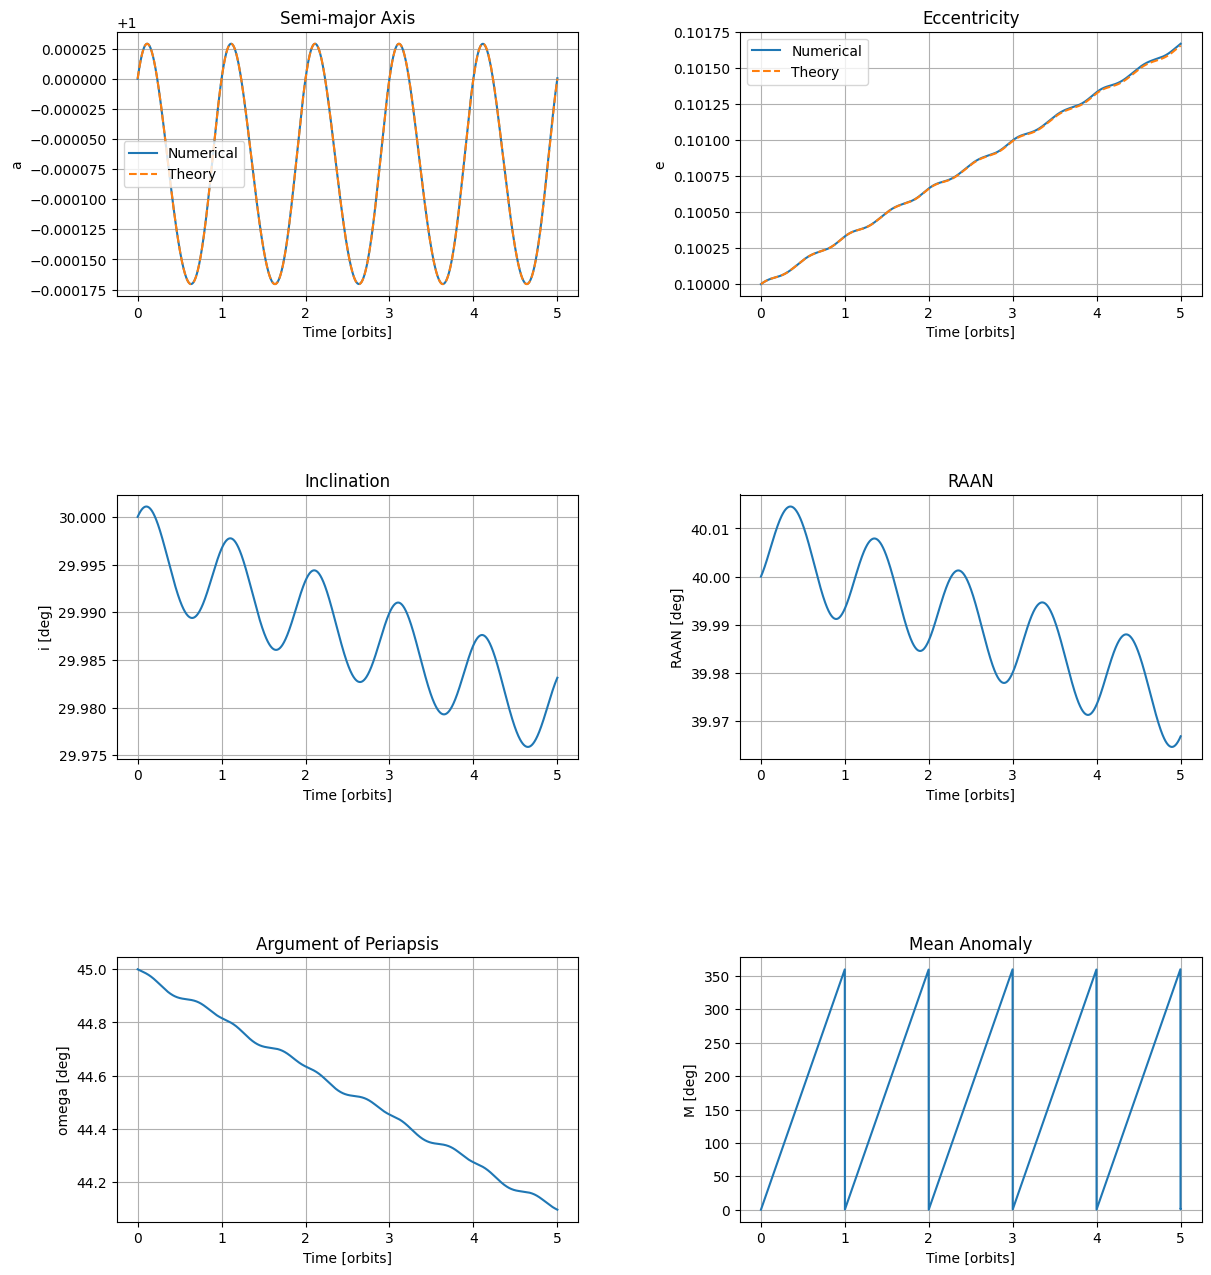


HW5 Part (c) Comparison

Initial semi-major axis a0 = 1.0
Initial eccentricity e0 = 0.1
Perturbing acceleration a_s = 0.0001

Semi-major axis comparison:
Numerical min/max = 0.99982962, 1.00002904
Theory    min/max = 0.99982954, 1.00002904

Eccentricity comparison:
Numerical min/max = 0.10000000, 0.10167032
Theory    min/max = 0.10000000, 0.10165773


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# HW5 Part (c)
# Constant z-direction acceleration perturbation
# Compare numerical osculating elements with theory


mu = 1.0

a0 = 1.0
e0 = 0.1
i0 = np.deg2rad(30.0)
Omega0 = np.deg2rad(40.0)
omega0 = np.deg2rad(45.0)
M0 = 0.0

a_s = 1e-4
a_pert = np.array([0.0, 0.0, a_s])

n0 = np.sqrt(mu / a0**3)
T0 = 2 * np.pi / n0

num_orbits = 5
t_final = num_orbits * T0
t_eval = np.linspace(0, t_final, 3000)

# Kepler solvers
def solve_kepler_wrapped(M, e, tol=1e-12):
    M = np.mod(M, 2*np.pi)

    if np.isscalar(M):
        E = M
    else:
        E = M.copy()

    for _ in range(50):
        f = E - e*np.sin(E) - M
        fp = 1 - e*np.cos(E)
        dE = -f / fp
        E = E + dE

        if np.max(np.abs(dE)) < tol:
            break

    return E


def solve_kepler_unwrapped(M, e, tol=1e-12):
    if np.isscalar(M):
        E = M
    else:
        E = M.copy()

    for _ in range(50):
        f = E - e*np.sin(E) - M
        fp = 1 - e*np.cos(E)
        dE = -f / fp
        E = E + dE

        if np.max(np.abs(dE)) < tol:
            break

    return E

# Convert Orbital Elements -> Cartesian State
def elements_to_rv(a, e, inc, Omega, omega, M, mu):
    E = solve_kepler_wrapped(M, e)

    r_pf = np.array([
        a * (np.cos(E) - e),
        a * np.sqrt(1 - e**2) * np.sin(E),
        0.0
    ])

    r_mag = a * (1 - e*np.cos(E))

    v_pf = np.array([
        -np.sqrt(mu*a) * np.sin(E) / r_mag,
        np.sqrt(mu*a) * np.sqrt(1 - e**2) * np.cos(E) / r_mag,
        0.0
    ])

    cO, sO = np.cos(Omega), np.sin(Omega)
    ci, si = np.cos(inc), np.sin(inc)
    cw, sw = np.cos(omega), np.sin(omega)

    R3_O = np.array([
        [cO, -sO, 0],
        [sO,  cO, 0],
        [0,   0,  1]
    ])

    R1_i = np.array([
        [1, 0, 0],
        [0, ci, -si],
        [0, si,  ci]
    ])

    R3_w = np.array([
        [cw, -sw, 0],
        [sw,  cw, 0],
        [0,   0,  1]
    ])

    Q = R3_O @ R1_i @ R3_w

    r_vec = Q @ r_pf
    v_vec = Q @ v_pf

    return r_vec, v_vec

# Convert Cartesian State -> Orbital Elements
def rv_to_elements(r, v, mu):
    r_mag = np.linalg.norm(r)
    v_mag = np.linalg.norm(v)

    h = np.cross(r, v)
    h_mag = np.linalg.norm(h)

    k_hat = np.array([0.0, 0.0, 1.0])
    N = np.cross(k_hat, h)
    N_mag = np.linalg.norm(N)

    e_vec = np.cross(v, h)/mu - r/r_mag
    e = np.linalg.norm(e_vec)

    energy = v_mag**2 / 2 - mu / r_mag
    a = -mu / (2 * energy)

    inc = np.arccos(h[2] / h_mag)

    Omega = np.arctan2(N[1], N[0])
    Omega = np.mod(Omega, 2*np.pi)

    omega = np.arccos(np.dot(N, e_vec) / (N_mag * e))
    if e_vec[2] < 0:
        omega = 2*np.pi - omega

    f = np.arccos(np.dot(e_vec, r) / (e * r_mag))
    if np.dot(r, v) < 0:
        f = 2*np.pi - f

    E = 2 * np.arctan2(
        np.sqrt(1 - e) * np.sin(f/2),
        np.sqrt(1 + e) * np.cos(f/2)
    )

    M = E - e*np.sin(E)
    M = np.mod(M, 2*np.pi)

    return a, e, inc, Omega, omega, M

# Dynamics
def dynamics(t, y):
    r = y[:3]
    v = y[3:]

    r_mag = np.linalg.norm(r)

    a_grav = -mu * r / r_mag**3
    a_total = a_grav + a_pert

    return np.hstack((v, a_total))

# Initial State
r0, v0 = elements_to_rv(
    a0, e0, i0, Omega0, omega0, M0, mu
)

y0 = np.hstack((r0, v0))

# Integrate
sol = solve_ivp(
    dynamics,
    [0, t_final],
    y0,
    t_eval=t_eval,
    rtol=1e-10,
    atol=1e-12
)

# Numerical Osculating Elements
a_num = []
e_num = []
i_num = []
Omega_num = []
omega_num = []
M_num = []

for k in range(len(sol.t)):
    r = sol.y[:3, k]
    v = sol.y[3:, k]

    a, e, inc, Omega, omega, M = rv_to_elements(r, v, mu)

    a_num.append(a)
    e_num.append(e)
    i_num.append(inc)
    Omega_num.append(Omega)
    omega_num.append(omega)
    M_num.append(M)

a_num = np.array(a_num)
e_num = np.array(e_num)
i_num = np.array(i_num)
Omega_num = np.array(Omega_num)
omega_num = np.array(omega_num)
M_num = np.array(M_num)

# Theory from Part (a)
M_theory = n0 * sol.t

# Use unwrapped eccentric anomaly so E grows continuously over many orbits.
E_theory = solve_kepler_unwrapped(M_theory, e0)

beta = np.sqrt(1 - e0**2)

Delta_a = (
    (2 * np.sin(i0) / n0**2)
    *
    (
        beta * np.cos(omega0) * np.sin(E_theory)
        -
        np.sin(omega0) * (1 - np.cos(E_theory))
    )
    * a_s
)

Delta_e = (
    (beta * np.sin(i0) / (n0**2 * a0))
    *
    (
        np.cos(omega0)
        *
        (
            (3/2) * E_theory
            -
            2 * e0 * np.sin(E_theory)
            +
            (1/4) * np.sin(2 * E_theory)
        )
        -
        (beta / 4)
        * np.sin(omega0)
        * (1 - np.cos(2 * E_theory))
    )
    * a_s
)

a_theory = a0 + Delta_a
e_theory = e0 + Delta_e

# Plot 3D Trajectory
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

ax.plot(sol.y[0], sol.y[1], sol.y[2], linewidth=1.5)
ax.scatter(sol.y[0, 0], sol.y[1, 0], sol.y[2, 0], marker='o', s=60, label='Start')
ax.scatter(sol.y[0, -1], sol.y[1, -1], sol.y[2, -1], marker='s', s=60, label='End')

ax.set_title('3D Numerical Trajectory')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.legend()

plt.tight_layout()

# Plot Orbital Elements
time_orbits = sol.t / T0

fig, axs = plt.subplots(3, 2, figsize=(14, 14))
axs = axs.flatten()

axs[0].plot(time_orbits, a_num, label='Numerical')
axs[0].plot(time_orbits, a_theory, '--', label='Theory')
axs[0].set_title('Semi-major Axis')
axs[0].set_ylabel('a')
axs[0].legend()

axs[1].plot(time_orbits, e_num, label='Numerical')
axs[1].plot(time_orbits, e_theory, '--', label='Theory')
axs[1].set_title('Eccentricity')
axs[1].set_ylabel('e')
axs[1].legend()

axs[2].plot(time_orbits, np.rad2deg(i_num))
axs[2].set_title('Inclination')
axs[2].set_ylabel('i [deg]')

axs[3].plot(time_orbits, np.rad2deg(Omega_num))
axs[3].set_title('RAAN')
axs[3].set_ylabel('RAAN [deg]')

axs[4].plot(time_orbits, np.rad2deg(omega_num))
axs[4].set_title('Argument of Periapsis')
axs[4].set_ylabel('omega [deg]')

axs[5].plot(time_orbits, np.rad2deg(M_num))
axs[5].set_title('Mean Anomaly')
axs[5].set_ylabel('M [deg]')

for ax in axs:
    ax.set_xlabel('Time [orbits]')
    ax.grid(True)

fig.subplots_adjust(
    hspace=0.75,
    wspace=0.35,
    top=0.92,
    bottom=0.07
)

plt.show()

# Print comparison
print('\nHW5 Part (c) Comparison\n')

print(f'Initial semi-major axis a0 = {a0}')
print(f'Initial eccentricity e0 = {e0}')
print(f'Perturbing acceleration a_s = {a_s}\n')

print('Semi-major axis comparison:')
print(f'Numerical min/max = {np.min(a_num):.8f}, {np.max(a_num):.8f}')
print(f'Theory    min/max = {np.min(a_theory):.8f}, {np.max(a_theory):.8f}\n')

print('Eccentricity comparison:')
print(f'Numerical min/max = {np.min(e_num):.8f}, {np.max(e_num):.8f}')
print(f'Theory    min/max = {np.min(e_theory):.8f}, {np.max(e_theory):.8f}')

In [4]:
# HW5 Part (d): Mean short-period values
import numpy as np

# Re-define constants in case this cell is run independently
mu = 1.0

a0 = 1.0
e0 = 0.1
i0 = np.deg2rad(30.0)
omega0 = np.deg2rad(45.0)

a_s = 1e-4

n0 = np.sqrt(mu / a0**3)

# Analytical averages from Part (d)
Delta_a_mean_theory = -(
    (2 + e0)
    * np.sin(i0)
    * np.sin(omega0)
    / n0**2
) * a_s

Delta_ep_mean_theory = -(
    (1 - e0**2)
    * np.sin(i0)
    * np.sin(omega0)
    / (4 * n0**2 * a0)
) * a_s

# Secular eccentricity rate from Part (b)
edot_bar = (
    3
    * np.sqrt(1 - e0**2)
    * np.sin(i0)
    * np.cos(omega0)
    / (2 * n0 * a0)
) * a_s

# Numerical short-period quantities
Delta_a_num = a_num - a0

Delta_ep_num = (e_num - e0) - edot_bar * sol.t

# Numerical mean values
Delta_a_mean_num = (
    np.trapz(Delta_a_num, sol.t)
    / (sol.t[-1] - sol.t[0])
)

Delta_ep_mean_num = (
    np.trapz(Delta_ep_num, sol.t)
    / (sol.t[-1] - sol.t[0])
)

# Print comparison
print('\nHW5 Part (d) Mean Short-Period Comparison\n')

print('Semi-major axis short-period mean:')
print(f'Theory     = {Delta_a_mean_theory:.10e}')
print(f'Numerical  = {Delta_a_mean_num:.10e}')
print(f'Difference = {Delta_a_mean_num - Delta_a_mean_theory:.10e}\n')

print('Eccentricity short-period mean:')
print(f'Theory     = {Delta_ep_mean_theory:.10e}')
print(f'Numerical  = {Delta_ep_mean_num:.10e}')
print(f'Difference = {Delta_ep_mean_num - Delta_ep_mean_theory:.10e}')


HW5 Part (d) Mean Short-Period Comparison

Semi-major axis short-period mean:
Theory     = -7.4246212025e-05
Numerical  = -7.4187168508e-05
Difference = 5.9043516116e-08

Eccentricity short-period mean:
Theory     = -8.7504464172e-06
Numerical  = -4.6100227859e-06
Difference = 4.1404236313e-06
